In [4]:
# read data

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load data
# -------------------------------
df = pd.read_csv("../data/processed/state_year_panel.csv")

In [ ]:
# Main DiD treatment variable
df["did"] = df["treated"] * df["post"]

In [ ]:
# -------------------------------
# 2. Main DiD model
# -------------------------------
# Model:
# outcome_st = alpha_s + gamma_t + beta * (treated_s × post_st) + e_st
#
# Here beta is the DiD estimate.

main_formula = """
fatality_rate_per_10k_reg ~ did + C(state) + C(year)
"""

main_model = smf.ols(main_formula, data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["state"]}
)

print("\n==============================")
print("MAIN DID MODEL")
print("==============================")
print(main_model.summary())

beta_main = main_model.params["did"]
se_main = main_model.bse["did"]
p_main = main_model.pvalues["did"]

print("\nMain DiD estimate:")
print(f"beta = {beta_main:.4f}")
print(f"SE   = {se_main:.4f}")
print(f"p    = {p_main:.4f}")


MAIN DID MODEL
                                OLS Regression Results                               
Dep. Variable:     fatality_rate_per_10k_reg   R-squared:                       0.125
Model:                                   OLS   Adj. R-squared:                  0.075
Method:                        Least Squares   F-statistic:                     11.35
Date:                       Mon, 20 Apr 2026   Prob (F-statistic):           1.89e-13
Time:                               16:03:43   Log-Likelihood:                -6083.1
No. Observations:                       1428   AIC:                         1.232e+04
Df Residuals:                           1349   BIC:                         1.274e+04
Df Model:                                 78                                         
Covariance Type:                     cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

/Users/grace/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 78, but rank is 28
  warnings.warn('covariance of constraints does not have full '


## Main model we should use

In [ ]:
# -------------------------------
# 3. Sensitivity analysis:
#    exclude suspicious_low registration years
# -------------------------------
df_clean = df[df["reg_data_quality_flag"] == "ok"].copy()

clean_model = smf.ols(main_formula, data=df_clean).fit(
    cov_type="cluster", cov_kwds={"groups": df_clean["state"]}
)

print("\n==============================")
print("DID MODEL EXCLUDING suspicious_low ROWS")
print("==============================")
print(clean_model.summary())

beta_clean = clean_model.params["did"]
se_clean = clean_model.bse["did"]
p_clean = clean_model.pvalues["did"]

print("\nClean-sample DiD estimate:")
print(f"beta = {beta_clean:.4f}")
print(f"SE   = {se_clean:.4f}")
print(f"p    = {p_clean:.4f}")


DID MODEL EXCLUDING suspicious_low ROWS
                                OLS Regression Results                               
Dep. Variable:     fatality_rate_per_10k_reg   R-squared:                       0.621
Model:                                   OLS   Adj. R-squared:                  0.599
Method:                        Least Squares   F-statistic:                     11.46
Date:                       Mon, 20 Apr 2026   Prob (F-statistic):           1.55e-13
Time:                               16:05:01   Log-Likelihood:                -3792.4
No. Observations:                       1424   AIC:                             7743.
Df Residuals:                           1345   BIC:                             8158.
Df Model:                                 78                                         
Covariance Type:                     cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975

/Users/grace/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 78, but rank is 28
  warnings.warn('covariance of constraints does not have full '


In [ ]:
# -------------------------------
# 3. Sensitivity analysis:
#    exclude suspicious_low registration years
# -------------------------------
df_clean = df[df["reg_data_quality_flag"] == "ok"].copy()

clean_model = smf.ols(main_formula, data=df_clean).fit(
    cov_type="cluster", cov_kwds={"groups": df_clean["state"]}
)

print("\n==============================")
print("DID MODEL EXCLUDING suspicious_low ROWS")
print("==============================")
print(clean_model.summary())

beta_clean = clean_model.params["did"]
se_clean = clean_model.bse["did"]
p_clean = clean_model.pvalues["did"]

print("\nClean-sample DiD estimate:")
print(f"beta = {beta_clean:.4f}")
print(f"SE   = {se_clean:.4f}")
print(f"p    = {p_clean:.4f}")

# -------------------------------
# 4. Robustness model:
#    population-based outcome
# -------------------------------
robust_formula = """
fatality_rate_per_100k_pop ~ did + C(state) + C(year)
"""

robust_model = smf.ols(robust_formula, data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["state"]}
)

print("\n==============================")
print("ROBUSTNESS MODEL: PER 100K POP")
print("==============================")
print(robust_model.summary())

beta_robust = robust_model.params["did"]
se_robust = robust_model.bse["did"]
p_robust = robust_model.pvalues["did"]

print("\nRobustness DiD estimate:")
print(f"beta = {beta_robust:.4f}")
print(f"SE   = {se_robust:.4f}")
print(f"p    = {p_robust:.4f}")


DID MODEL EXCLUDING suspicious_low ROWS
                                OLS Regression Results                               
Dep. Variable:     fatality_rate_per_10k_reg   R-squared:                       0.621
Model:                                   OLS   Adj. R-squared:                  0.599
Method:                        Least Squares   F-statistic:                     11.46
Date:                       Mon, 20 Apr 2026   Prob (F-statistic):           1.55e-13
Time:                               16:05:21   Log-Likelihood:                -3792.4
No. Observations:                       1424   AIC:                             7743.
Df Residuals:                           1345   BIC:                             8158.
Df Model:                                 78                                         
Covariance Type:                     cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975

/Users/grace/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 78, but rank is 28
  warnings.warn('covariance of constraints does not have full '
/Users/grace/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 78, but rank is 28
  warnings.warn('covariance of constraints does not have full '


In [ ]:
# -------------------------------
# 5. Event study setup
# -------------------------------

# We focus on treated units for event-time dummies,
# but controls remain in the regression as the comparison group.
#
# Common choice:
# - Keep event time in a window, e.g. [-5, +5]
# - Omit event_time = -1 as the reference period
#
# Note: In staggered-adoption settings, TWFE event-study coefficients
# can have weighting issues. This is still the standard baseline plot
# for many class projects / first-pass analysis.

event_df = df.copy()


# Create capped event-time variable for treated states only
# Controls stay as NaN and will simply not get event dummies

min_k, max_k = -5, 5
reference_period = -1

event_df["event_time_capped"] = event_df["event_time"]
event_df.loc[event_df["event_time_capped"] < min_k, "event_time_capped"] = min_k
event_df.loc[event_df["event_time_capped"] > max_k, "event_time_capped"] = max_k


def event_col_name(k):
    if k < 0:
        return f"event_m{abs(k)}"
    elif k > 0:
        return f"event_p{k}"
    else:
        return "event_0"


event_times = list(range(min_k, max_k + 1))

for k in event_times:
    if k == reference_period:
        continue
    col = event_col_name(k)
    event_df[col] = (
        (event_df["treated"] == 1) & (event_df["event_time_capped"] == k)
    ).astype(int)

event_terms = " + ".join(
    [event_col_name(k) for k in event_times if k != reference_period]
)

event_formula = f"""
fatality_rate_per_10k_reg ~ {event_terms} + C(state) + C(year)
"""

event_model = smf.ols(event_formula, data=event_df).fit(
    cov_type="cluster", cov_kwds={"groups": event_df["state"]}
)

print("\n==============================")
print("EVENT STUDY MODEL")
print("==============================")
print(event_model.summary())


EVENT STUDY MODEL
                                OLS Regression Results                               
Dep. Variable:     fatality_rate_per_10k_reg   R-squared:                       0.126
Model:                                   OLS   Adj. R-squared:                  0.069
Method:                        Least Squares   F-statistic:                     13.34
Date:                       Mon, 20 Apr 2026   Prob (F-statistic):           2.14e-15
Time:                               16:08:05   Log-Likelihood:                -6082.9
No. Observations:                       1428   AIC:                         1.234e+04
Df Residuals:                           1340   BIC:                         1.281e+04
Df Model:                                 87                                         
Covariance Type:                     cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------

/Users/grace/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 87, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [ ]:
event_results = []

for k in event_times:
    if k == reference_period:
        continue

    term = event_col_name(k)
    coef = event_model.params.get(term, np.nan)
    se = event_model.bse.get(term, np.nan)

    event_results.append(
        {
            "event_time": k,
            "coef": coef,
            "se": se,
            "ci_low": coef - 1.96 * se,
            "ci_high": coef + 1.96 * se,
        }
    )

event_results = pd.DataFrame(event_results).sort_values("event_time")
print(event_results)

   event_time      coef        se    ci_low   ci_high
0          -5 -0.705145  2.822492 -6.237230  4.826940
1          -4  1.232358  3.059079 -4.763437  7.228153
2          -3  1.433349  3.122243 -4.686248  7.552946
3          -2  1.259119  2.891378 -4.407982  6.926221
4           0  2.071756  2.304795 -2.445643  6.589155
5           1  2.626834  2.171698 -1.629694  6.883363
6           2  0.199951  2.787548 -5.263644  5.663545
7           3  2.462738  2.761086 -2.948990  7.874466
8           4 -0.082702  3.087294 -6.133797  5.968393
9           5  2.662251  2.858591 -2.940587  8.265090


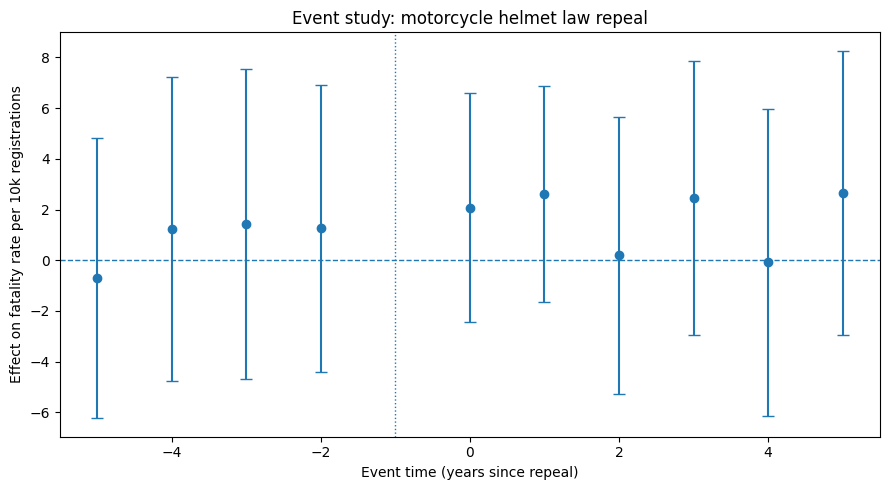

In [ ]:
plt.figure(figsize=(9, 5))
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(-1, linestyle=":", linewidth=1)

plt.errorbar(
    event_results["event_time"],
    event_results["coef"],
    yerr=1.96 * event_results["se"],
    fmt="o",
    capsize=4,
)

plt.xlabel("Event time (years since repeal)")
plt.ylabel("Effect on fatality rate per 10k registrations")
plt.title("Event study: motorcycle helmet law repeal")
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------
# 8. Compact results table
# -------------------------------
results_table = pd.DataFrame(
    {
        "model": [
            "Main DiD: rate per 10k registrations",
            "Exclude suspicious_low",
            "Robustness: rate per 100k population",
        ],
        "coef_did": [
            main_model.params.get("did", np.nan),
            clean_model.params.get("did", np.nan),
            robust_model.params.get("did", np.nan),
        ],
        "se": [
            main_model.bse.get("did", np.nan),
            clean_model.bse.get("did", np.nan),
            robust_model.bse.get("did", np.nan),
        ],
        "p_value": [
            main_model.pvalues.get("did", np.nan),
            clean_model.pvalues.get("did", np.nan),
            robust_model.pvalues.get("did", np.nan),
        ],
    }
)

print("\n==============================")
print("RESULTS TABLE")
print("==============================")
print(results_table)


RESULTS TABLE
                                  model  coef_did        se   p_value
0  Main DiD: rate per 10k registrations  1.999106  0.930410  0.031664
1                Exclude suspicious_low  1.612892  0.764746  0.034940
2  Robustness: rate per 100k population  0.377723  0.126170  0.002756


## Graph 1: Average fatality rate over time, treated vs control

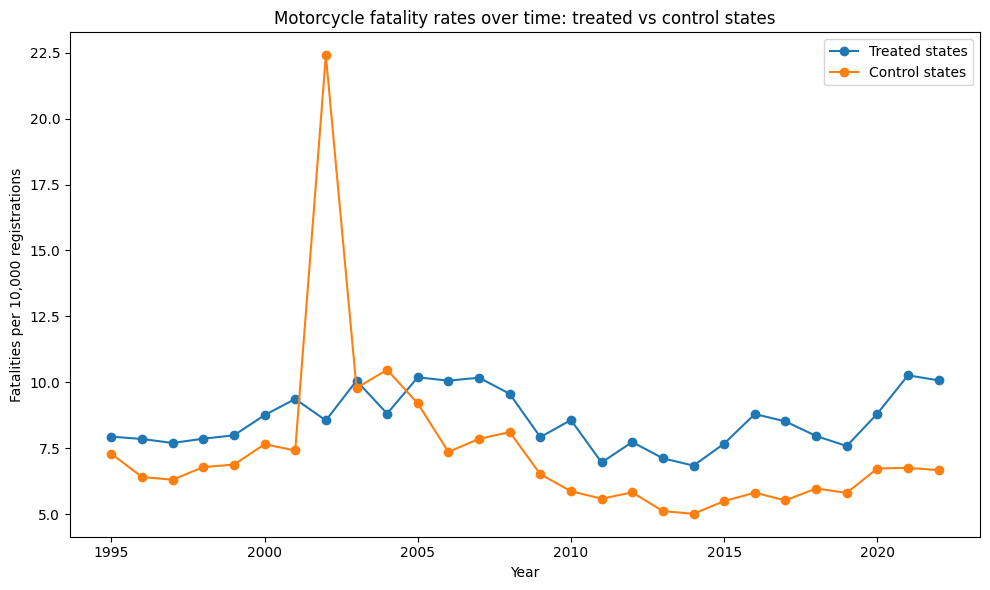

In [ ]:
# Average outcome by year and treatment group
avg_trends = (
    df.groupby(["year", "treated"])["fatality_rate_per_10k_reg"].mean().reset_index()
)

treated_trend = avg_trends[avg_trends["treated"] == 1]
control_trend = avg_trends[avg_trends["treated"] == 0]

plt.figure(figsize=(10, 6))
plt.plot(
    treated_trend["year"],
    treated_trend["fatality_rate_per_10k_reg"],
    marker="o",
    label="Treated states",
)
plt.plot(
    control_trend["year"],
    control_trend["fatality_rate_per_10k_reg"],
    marker="o",
    label="Control states",
)

plt.xlabel("Year")
plt.ylabel("Fatalities per 10,000 registrations")
plt.title("Motorcycle fatality rates over time: treated vs control states")
plt.legend()
plt.tight_layout()
plt.show()